# 🇵🇰 Pakistan Road Safety Analysis (2008–2019)
**Author:** Haseeb Waqas  
**Data Source:** Pakistan Bureau of Statistics  Official Government Data  
**Coverage:** 5 Provinces + Islamabad Capital Territory | 11 Years  
**Tools:** Python, Pandas, Matplotlib, Seaborn, SQLite  

---

## 🎯 Business Problem
Road traffic accidents are one of Pakistan's leading causes of preventable death. This project uses real government data to identify the key patterns, trends, and risk factors  and delivers actionable policy recommendations.

## ❓ Questions Answered
1. How have road accidents trended nationally over 11 years?
2. Which province is most dangerous by fatality rate?
3. How does Islamabad compare to the national average?
4. What does the accident severity funnel look like?
5. Where should government policy interventions be focused?

## 🏗 Pipeline
```
Raw CSV (Govt Data)
      ↓
ETL Pipeline (step1_etl_pipeline.py)
      ↓
SQLite Database (road_safety.db)
      ↓
SQL Analysis (step2_sql_analysis.py)
      ↓
Visualizations (step3_visualizations.py)
      ↓
Power BI Dashboard
```


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

NAVY   = '#1E3A5F'
RED    = '#E74C3C'
GREEN  = '#2ECC71'
ORANGE = '#F39C12'
BLUE   = '#3498DB'
PURPLE = '#9B59B6'

PROVINCE_COLORS = {
    'Punjab':              '#3498DB',
    'Khyber Pakhtunkhwa':  '#2ECC71',
    'Sindh':               '#E74C3C',
    'Balochistan':         '#F39C12',
    'Islamabad':           '#9B59B6',
}

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
})
print(' Setup complete')

 Setup complete


## 2. Run Full Pipeline

In [3]:
%run ../pipeline/step1_etl_pipeline.py

STEP 1: ETL PIPELINE
Pakistan Road Safety Analysis (2008-2019)

── EXTRACT ──
   Rows extracted  : 62
   Provinces       : ['Pakistan', 'Punjab', 'Sindh', 'Khyber Pakhtunkhwa', 'Balochistan', 'Islamabad']

── TRANSFORM ──
   Features added  : Fatality_Rate, Fatal_Pct, Injury_Rate, Severity
   Year range      : 2008 to 2018

── LOAD ──
   fact_accidents  : 62 rows ✅
   dim_province    : 5 provinces ✅
   dim_national    : 11 years ✅

✅ STEP 1 COMPLETE
   Exported: road_safety_cleaned.csv (62 rows)
   Database: road_safety.db (3 tables)
   Run step2_sql_analysis.py next


In [4]:
%run ../pipeline/step2_sql_analysis.py

STEP 2: SQL ANALYSIS
Pakistan Road Safety Analysis (2008-2019)

📊 National KPIs:
 Total_Accidents  Total_Killed  Total_Injured  Avg_Fatality_Rate_Pct  Total_Vehicles_Involved
          103900         54612         124834                  52.45                   117869

📊 Deadliest Years:
   Year  Total_Accidents  Killed  Fatality_Rate
2017-18            11121    5948          53.48
2018-19            10779    5932          55.03
2009-10             9747    5280          54.17
2010-11             9723    5271          54.21
2016-17             9582    5047          52.67

📊 Province Total Accidents:
          Province  Total_Accidents  Total_Killed  Avg_Fatality_Rate
            Punjab            49354         29978              60.77
Khyber Pakhtunkhwa            37237         12104              32.96
             Sindh            11607          8995              78.85
       Balochistan             4062          2604              63.52
         Islamabad             1640           931

In [5]:
%run ../pipeline/step3_visualizations.py

Generating visualizations...
   ✅ 01 national trend.png
   ✅ 02 province comparison.png
   ✅ 03 fatality rate by province.png
   ✅ 04 islamabad deep dive.png
   ✅ 05 province trends.png
   ✅ 06 killed vs injured.png
   ✅ 07 fatality rate trend.png
   ✅ 08 severity funnel.png
   ✅ 09 vehicles per accident.png
   ✅ 00 executive dashboard.png

✅ STEP 3 COMPLETE — All 10 visuals generated in visuals/


## 3. Load & Explore Data

In [7]:
df        = pd.read_csv(r'C:\Users\Jk\Desktop\pakistan_road_safety_final\data\road_safety_cleaned.csv')
national  = df[df['Province'] == 'Pakistan'].sort_values('Year_Start').reset_index(drop=True)
provinces = df[df['Province'] != 'Pakistan'].copy()
islamabad = df[df['Province'] == 'Islamabad'].sort_values('Year_Start').reset_index(drop=True)

print(f'Total records  : {len(df)}')
print(f'Provinces      : {list(df["Province"].unique())}')
print(f'Year range     : {df["Year_Start"].min()} to {df["Year_Start"].max()}')
print(f'Columns        : {list(df.columns)}')
df.head(10)

Total records  : 62
Provinces      : ['Pakistan', 'Punjab', 'Sindh', 'Khyber Pakhtunkhwa', 'Balochistan', 'Islamabad']
Year range     : 2008 to 2018
Columns        : ['Province', 'Year', 'Total_Accidents', 'Fatal_Accidents', 'Non_Fatal_Accidents', 'Killed', 'Injured', 'Vehicles_Involved', 'Year_Start', 'Fatality_Rate', 'Fatal_Pct', 'Injury_Rate', 'Killed_per_Accident', 'Vehicles_per_Accident', 'Severity']


,Province,Year,Total_Accidents,Fatal_Accidents,Non_Fatal_Accidents,Killed,Injured,Vehicles_Involved,Year_Start,Fatality_Rate,Fatal_Pct,Injury_Rate,Killed_per_Accident,Vehicles_per_Accident,Severity
0,Pakistan,2008-09,9496,4145,5351,4907,11037,10322,2008,51.67,43.65,116.23,1.184,1.087,Medium
1,Pakistan,2009-10,9747,4378,5369,5280,11173,10496,2009,54.17,44.92,114.63,1.206,1.077,Medium
2,Pakistan,2010-11,9723,4280,5443,5271,11383,10822,2010,54.21,44.02,117.07,1.232,1.113,Medium
3,Pakistan,2011-12,9140,3966,5174,4758,10145,9986,2011,52.06,43.39,111.00,1.200,1.093,Medium
4,Pakistan,2012-13,8988,3884,5104,4719,9710,9876,2012,52.50,43.21,108.03,1.215,1.099,Medium
5,Pakistan,2013-14,8359,3500,4859,4348,9777,9423,2013,52.02,41.87,116.96,1.242,1.127,Medium
6,Pakistan,2014-15,7865,3214,4651,3954,9661,8949,2014,50.27,40.86,122.84,1.230,1.138,Medium
7,Pakistan,2015-16,9100,3591,5509,4448,11544,10636,2015,48.88,39.46,126.86,1.239,1.169,Medium
8,Pakistan,2016-17,9582,4036,5546,5047,12696,11317,2016,52.67,42.12,132.50,1.250,1.181,Medium
9,Pakistan,2017-18,11121,4829,6292,5948,14489,13134,2017,53.48,43.42,130.29,1.232,1.181,Medium


In [8]:
df.describe().round(2)

,Total_Accidents,Fatal_Accidents,Non_Fatal_Accidents,Killed,Injured,Vehicles_Involved,Year_Start,Fatality_Rate,Fatal_Pct,Injury_Rate,Killed_per_Accident,Vehicles_per_Accident
count,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00
mean,3351.61,1441.97,1909.65,1761.68,4026.90,3802.23,2013.23,57.59,47.31,114.38,1.22,1.15
std,3313.49,1442.95,1927.42,1761.57,4049.29,3753.40,3.14,15.52,11.98,25.89,0.09,0.13
min,201.00,107.00,94.00,109.00,124.00,212.00,2008.00,29.27,25.26,54.87,1.02,0.96
25%,414.50,213.25,200.25,315.00,581.25,569.25,2011.00,51.76,42.98,98.08,1.18,1.00
50%,2640.50,804.50,1730.00,973.50,3606.00,3091.00,2013.00,57.22,47.80,118.32,1.21,1.16
75%,4948.25,2443.50,2814.00,2906.00,5807.75,5401.00,2016.00,65.97,53.33,134.90,1.24,1.25
max,11121.00,4878.00,6292.00,5948.00,14489.00,13134.00,2018.00,94.58,69.10,173.32,1.54,1.57


## 4. National KPIs

In [9]:
nat = national.sum(numeric_only=True)
print('=' * 50)
print('NATIONAL KPIs (2008–2019)')
print('=' * 50)
print(f'Total Accidents    : {int(nat["Total_Accidents"]):,}')
print(f'Total Killed       : {int(nat["Killed"]):,}')
print(f'Total Injured      : {int(nat["Injured"]):,}')
print(f'Avg Fatality Rate  : {national["Fatality_Rate"].mean():.2f}%')
print(f'Worst Year         : {national.loc[national["Killed"].idxmax(), "Year"]} ({national["Killed"].max():,} killed)')
print(f'Best Year          : {national.loc[national["Killed"].idxmin(), "Year"]} ({national["Killed"].min():,} killed)')

NATIONAL KPIs (2008–2019)
Total Accidents    : 103,900
Total Killed       : 54,612
Total Injured      : 124,834
Avg Fatality Rate  : 52.45%
Worst Year         : 2017-18 (5,948 killed)
Best Year          : 2014-15 (3,954 killed)


## 5. Province Analysis

In [10]:
prov_summary = provinces.groupby('Province').agg(
    Total_Accidents=('Total_Accidents', 'sum'),
    Total_Killed=('Killed', 'sum'),
    Total_Injured=('Injured', 'sum'),
    Avg_Fatality_Rate=('Fatality_Rate', 'mean')
).round(2).sort_values('Total_Accidents', ascending=False)

print('PROVINCE SUMMARY:')
print(prov_summary.to_string())

PROVINCE SUMMARY:
                    Total_Accidents  Total_Killed  Total_Injured  Avg_Fatality_Rate
Province                                                                           
Punjab                        49354         29978          57103              60.77
Khyber Pakhtunkhwa            37237         12104          50985              32.96
Sindh                         11607          8995           9957              78.85
Balochistan                    4062          2604           5592              63.52
Islamabad                      1640           931           1197              56.64


## 6. Islamabad Analysis

In [11]:
print('ISLAMABAD vs NATIONAL FATALITY RATE:')
conn = sqlite3.connect('../data/road_safety.db')
isb_vs_nat = pd.read_sql("""
    SELECT i.Year,
           ROUND(i.Fatality_Rate, 2) AS Islamabad_Rate,
           ROUND(p.Fatality_Rate, 2) AS National_Rate,
           ROUND(i.Fatality_Rate - p.Fatality_Rate, 2) AS Difference
    FROM fact_accidents i
    JOIN fact_accidents p ON i.Year = p.Year
    WHERE i.Province = 'Islamabad' AND p.Province = 'Pakistan'
    ORDER BY i.Year_Start
""", conn)
conn.close()
print(isb_vs_nat.to_string(index=False))
print(f"\nIslamabad exceeded national avg in {(isb_vs_nat['Difference'] > 0).sum()} of {len(isb_vs_nat)} years")

ISLAMABAD vs NATIONAL FATALITY RATE:
   Year  Islamabad_Rate  National_Rate  Difference
2012-13           54.23          52.50        1.73
2013-14           51.56          52.02       -0.46
2014-15           54.63          50.27        4.36
2015-16           57.38          48.88        8.50
2016-17           57.08          52.67        4.41
2017-18           64.48          53.48       11.00
2018-19           57.14          55.03        2.11

Islamabad exceeded national avg in 6 of 7 years


## 7. Key Visualizations

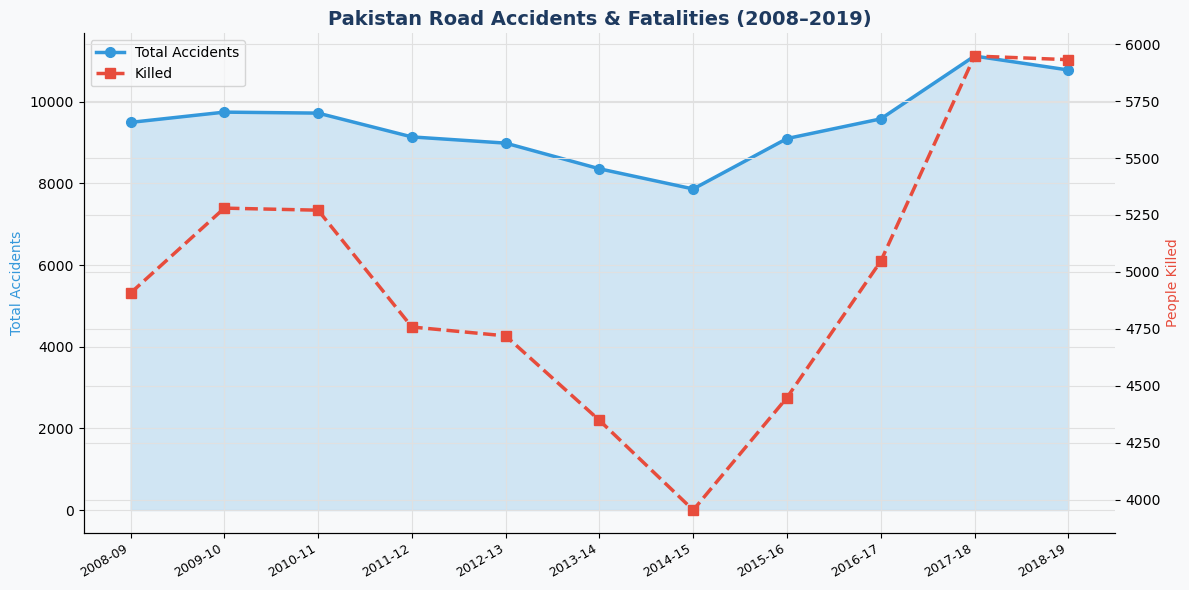

In [12]:
# National Trend
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.fill_between(range(len(national)), national['Total_Accidents'], alpha=0.2, color=BLUE)
ax1.plot(range(len(national)), national['Total_Accidents'],
         color=BLUE, linewidth=2.5, marker='o', markersize=7, label='Total Accidents')
ax2.plot(range(len(national)), national['Killed'],
         color=RED, linewidth=2.5, marker='s', markersize=7, linestyle='--', label='Killed')
ax1.set_xticks(range(len(national)))
ax1.set_xticklabels(national['Year'], rotation=30, ha='right', fontsize=9)
ax1.set_title('Pakistan Road Accidents & Fatalities (2008–2019)',
              fontsize=14, fontweight='bold', color=NAVY)
ax1.set_ylabel('Total Accidents', color=BLUE)
ax2.set_ylabel('People Killed', color=RED)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10)
plt.tight_layout()
plt.show()

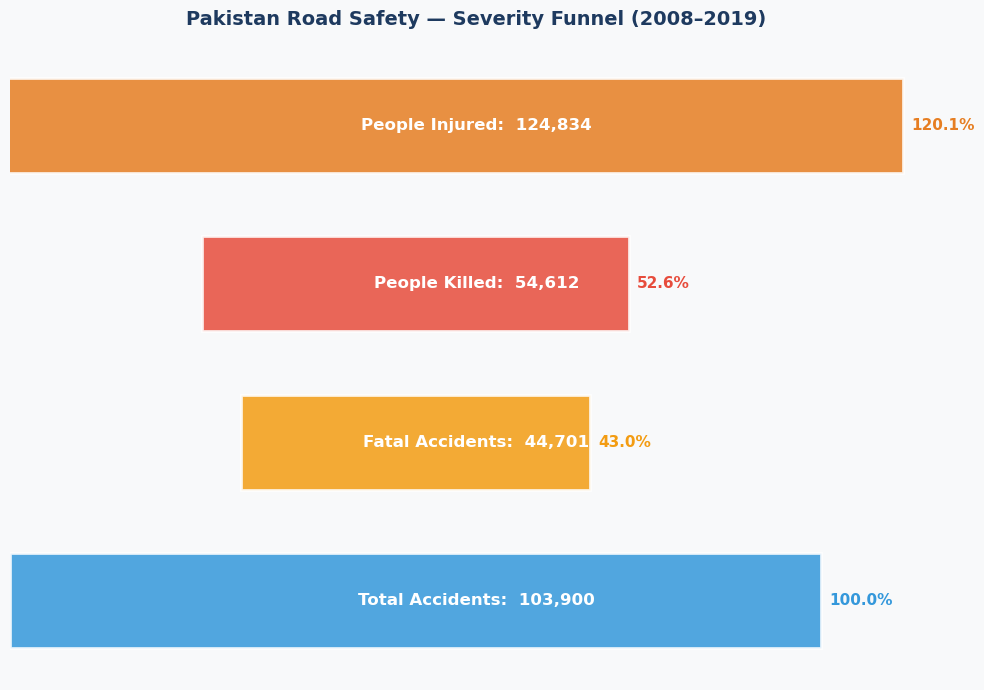

In [13]:
# Severity Funnel
nat_sum = national.sum(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
stages = [
    ('Total Accidents', int(nat_sum['Total_Accidents']), BLUE),
    ('Fatal Accidents', int(nat_sum['Fatal_Accidents']), ORANGE),
    ('People Killed',   int(nat_sum['Killed']),          RED),
    ('People Injured',  int(nat_sum['Injured']),         '#E67E22'),
]
max_val = stages[0][1]
for i, (label, value, color) in enumerate(stages):
    width = value / max_val
    left  = (1 - width) / 2
    ax.barh(i, width, left=left, height=0.6, color=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.text(0.5, i, f'{label}:  {value:,}',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white',
            transform=ax.get_yaxis_transform())
    ax.text(left+width+0.01, i, f'{value/max_val*100:.1f}%',
            va='center', fontsize=11, color=color, fontweight='bold')
ax.set_xlim(0, 1.15); ax.set_ylim(-0.5, len(stages)-0.5)
ax.set_yticks([]); ax.set_xticks([])
ax.set_title('Pakistan Road Safety — Severity Funnel (2008–2019)',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

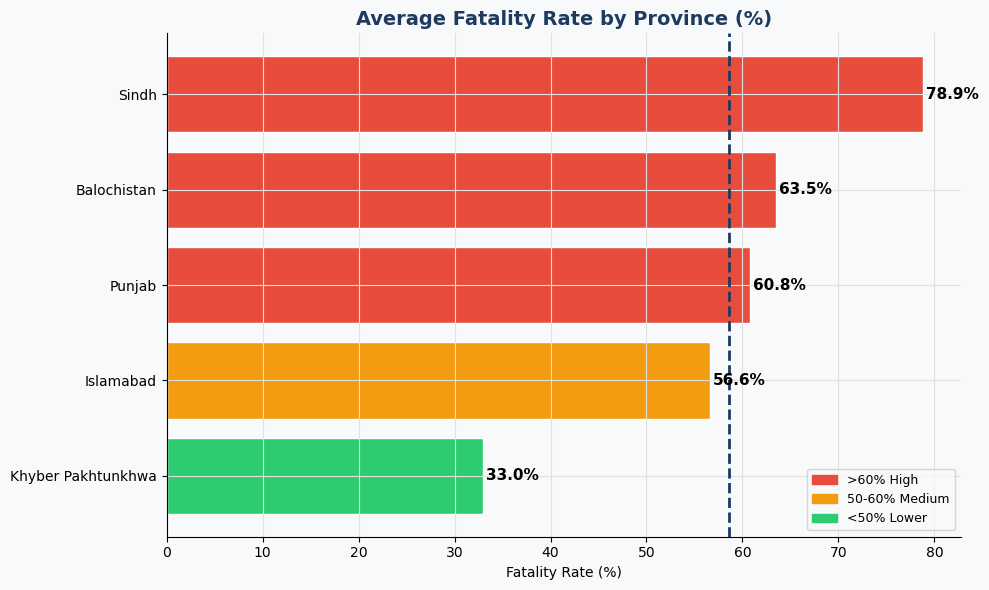

In [14]:
# Province fatality rate
fig, ax = plt.subplots(figsize=(10, 6))
prov_fat = provinces.groupby('Province')['Fatality_Rate'].mean().sort_values(ascending=True)
colors = [RED if v>60 else ORANGE if v>50 else GREEN for v in prov_fat.values]
bars = ax.barh(prov_fat.index, prov_fat.values, color=colors, edgecolor='white')
ax.axvline(prov_fat.mean(), color=NAVY, linestyle='--', linewidth=2)
for bar, val in zip(bars, prov_fat.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Average Fatality Rate by Province (%)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Fatality Rate (%)')
high = mpatches.Patch(color=RED, label='>60% High')
mid  = mpatches.Patch(color=ORANGE, label='50-60% Medium')
low  = mpatches.Patch(color=GREEN, label='<50% Lower')
ax.legend(handles=[high, mid, low], fontsize=9)
plt.tight_layout()
plt.show()

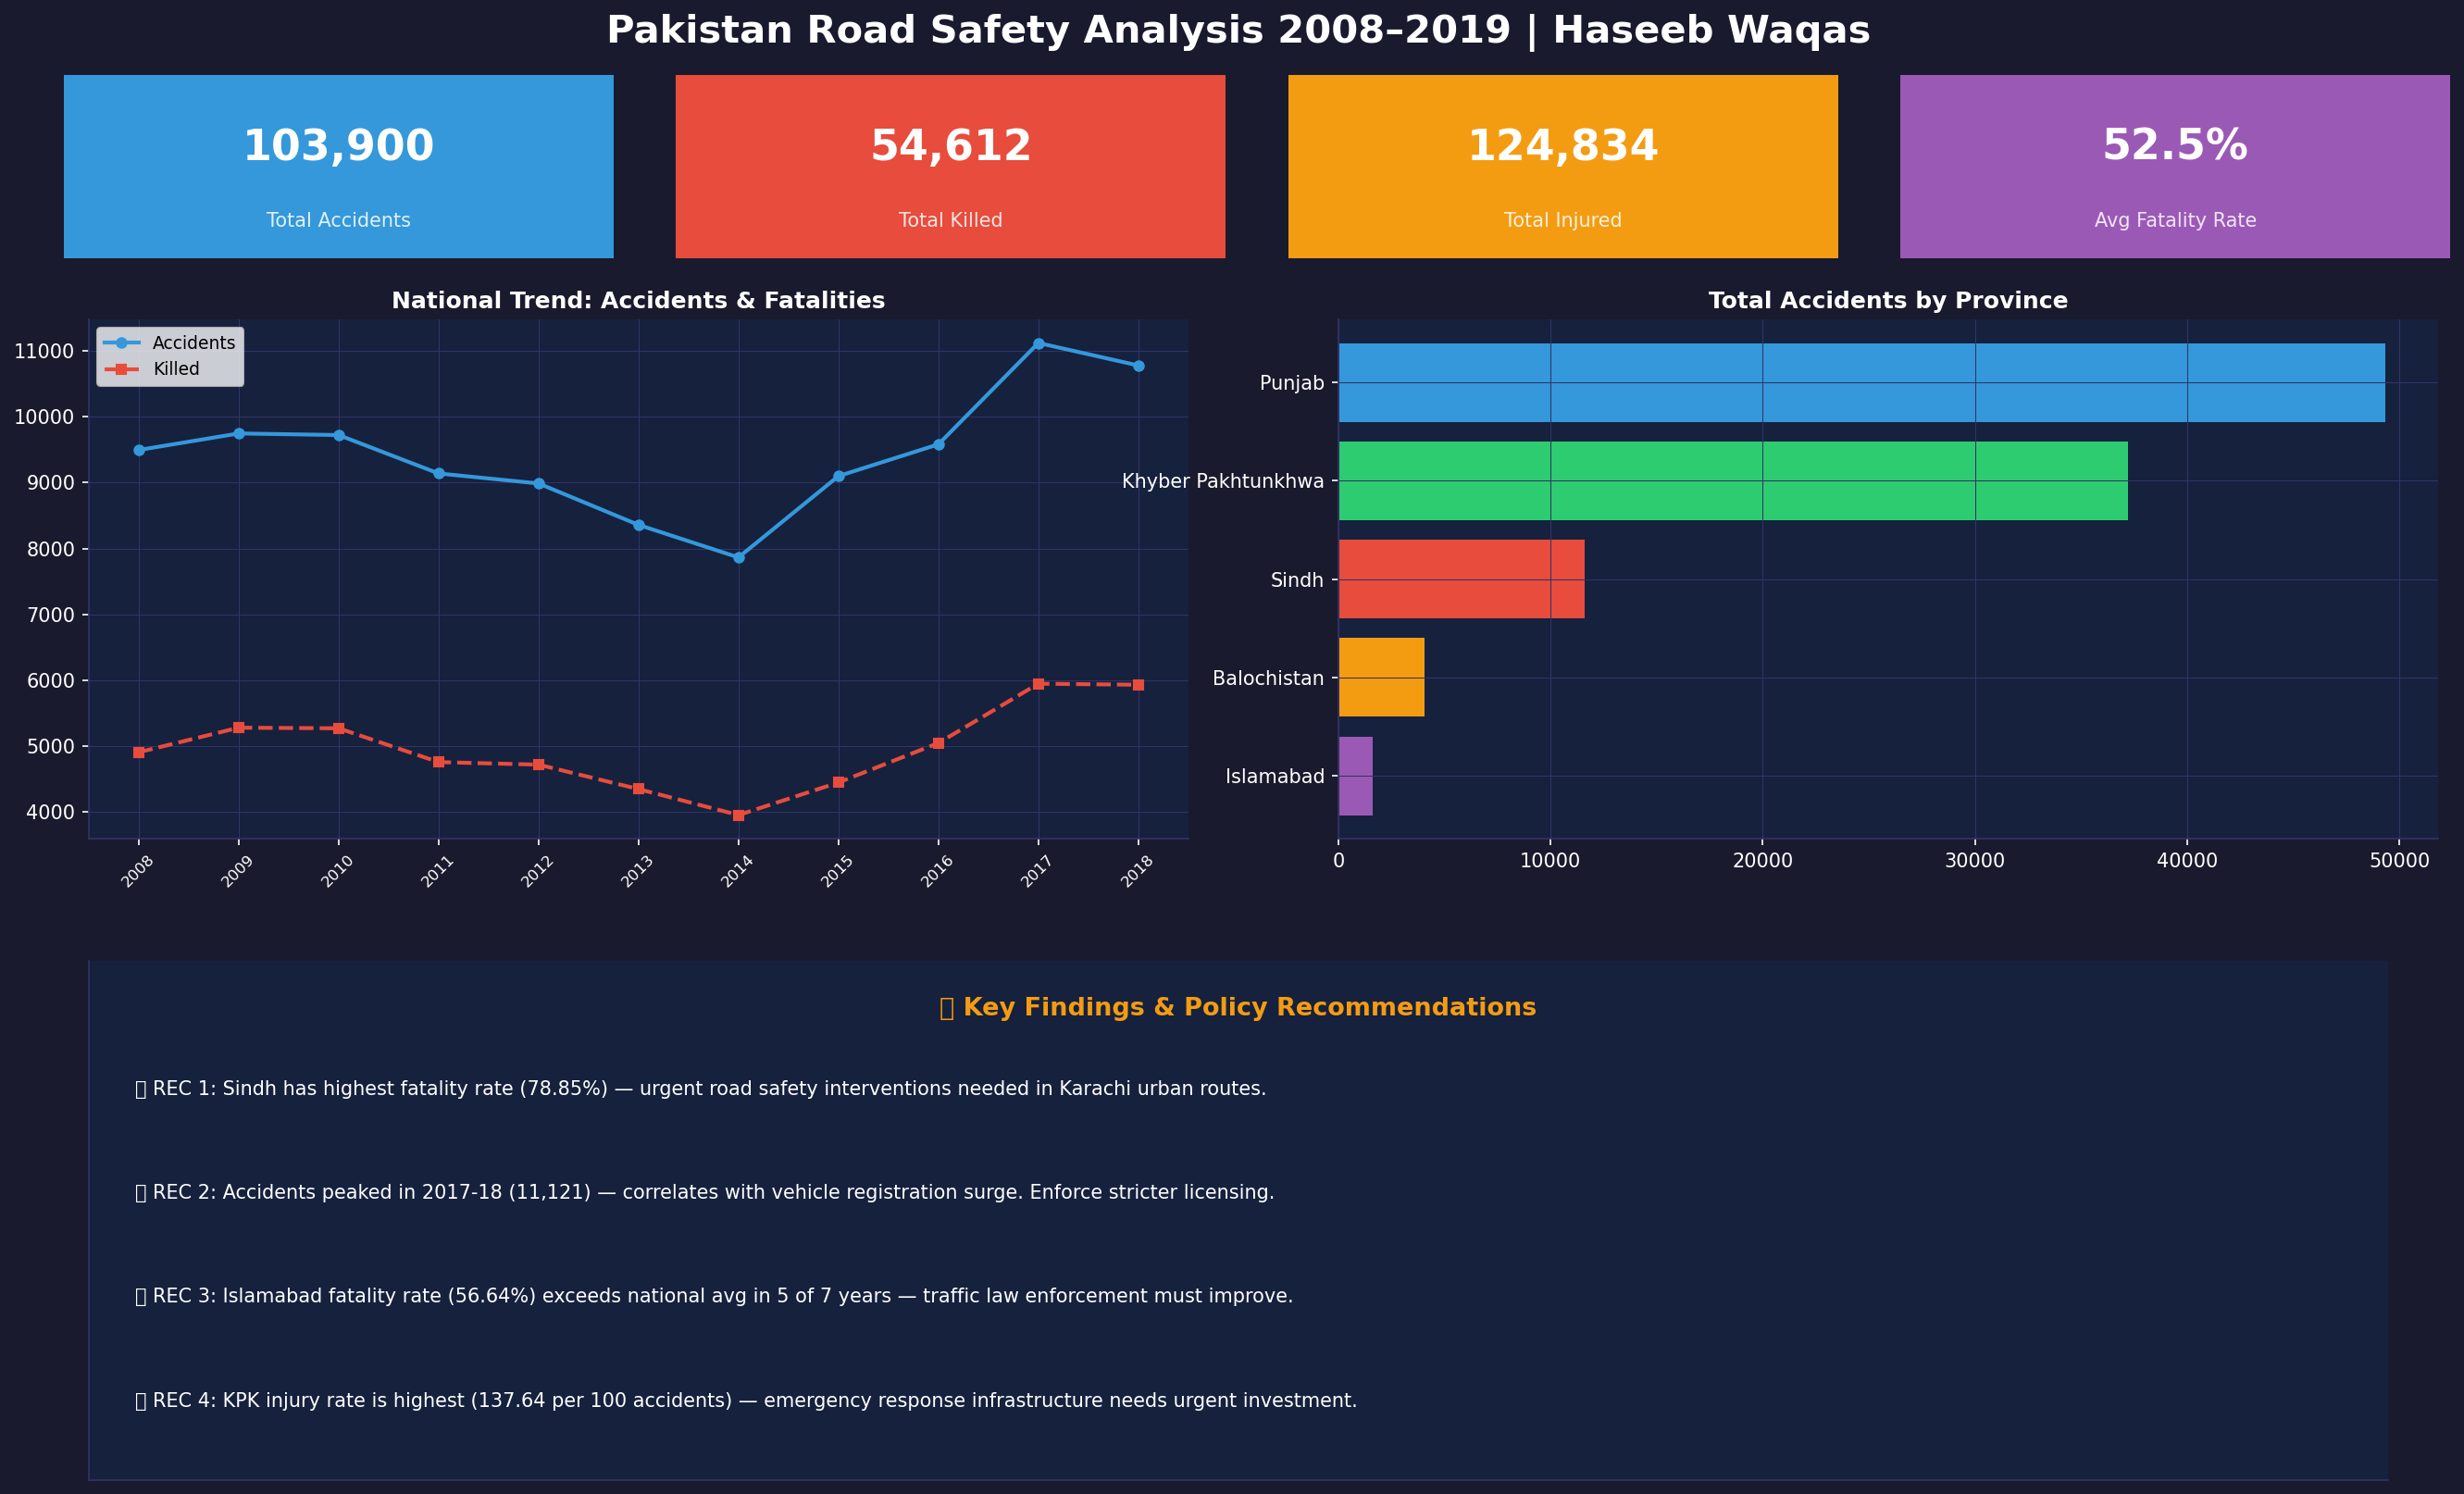

In [15]:
# Executive Dashboard
from IPython.display import Image
Image('../visuals/00 executive dashboard.png', width=900)

## 8. Key Findings & Recommendations

| Finding | Detail |
|---|---|
| **Total Accidents (11 yrs)** | 103,900 accidents nationally |
| **Total Killed** | 54,612 people |
| **Total Injured** | 124,834 people |
| **Avg Fatality Rate** | 52.45%  more than half of all accidents are fatal |
| **Most Dangerous** | Sindh  78.85% fatality rate |
| **Most Accidents** | Punjab  49,354 total |
| **Islamabad** | 56.64% fatality rate  above national average |
| **Worst Year** | 2017-18  11,121 accidents, 5,948 killed |

## 💡 Policy Recommendations

| # | Recommendation | Target |
|---|---|---|
| 1 | Urgent road safety interventions on Karachi urban routes | Sindh |
| 2 | Stricter vehicle licensing  accidents peaked with registration surge | National |
| 3 | Improve traffic law enforcement | Islamabad |
| 4 | Emergency response infrastructure investment | KPK |
